# BNPL Use Among Women: Does Having Children Matter?

## Motivation

Women are more likely than men to use Buy Now Pay Later (BNPL) services. One natural hypothesis is that this gap is partly driven by the financial demands of motherhood — childcare costs, school supplies, clothing, and other child-related expenses may push mothers toward deferred-payment options. This notebook investigates whether women with children in the household use BNPL at higher rates than women without children.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

df = pd.read_csv('../../data/data_merged.csv', low_memory=False)

women = df[df['ppgender'] == 'Female'].copy()
women['has_children'] = women['ppkid017'] > 0
women['bnpl_user'] = women['BNPL1'] == 'Yes'

n_women = len(women)
n_with_kids = women['has_children'].sum()
n_without_kids = (~women['has_children']).sum()

print(f"Total women in dataset:       {n_women:,}")
print(f"  With children (ppkid017>0): {n_with_kids:,} ({n_with_kids/n_women:.1%})")
print(f"  Without children:           {n_without_kids:,} ({n_without_kids/n_women:.1%})")

Total women in dataset:       23,388
  With children (ppkid017>0): 6,365 (27.2%)
  Without children:           17,023 (72.8%)


## Overall BNPL Adoption Rate: Women With vs. Without Children

In [7]:
rates = women.groupby('has_children')['bnpl_user'].mean().rename({False: 'No Children', True: 'Has Children'})
counts = women.groupby('has_children')['bnpl_user'].agg(['sum', 'count']).rename(index={False: 'No Children', True: 'Has Children'})

print("BNPL Adoption Rate:")
for label in ['No Children', 'Has Children']:
    n_users = counts.loc[label, 'sum']
    n_total = counts.loc[label, 'count']
    rate = rates[label]
    print(f"  {label}: {rate:.1%}  ({int(n_users):,} of {int(n_total):,})")

ct = pd.crosstab(women['has_children'], women['bnpl_user'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi-square test: \u03c7\u00b2={chi2:.2f}, p={p:.4f}")
if p < 0.05:
    print("  \u2192 Statistically significant difference (p < 0.05)")
else:
    print("  \u2192 No statistically significant difference (p \u2265 0.05)")

BNPL Adoption Rate:
  No Children: 11.8%  (2,015 of 17,023)
  Has Children: 18.6%  (1,187 of 6,365)

Chi-square test: χ²=181.35, p=0.0000
  → Statistically significant difference (p < 0.05)


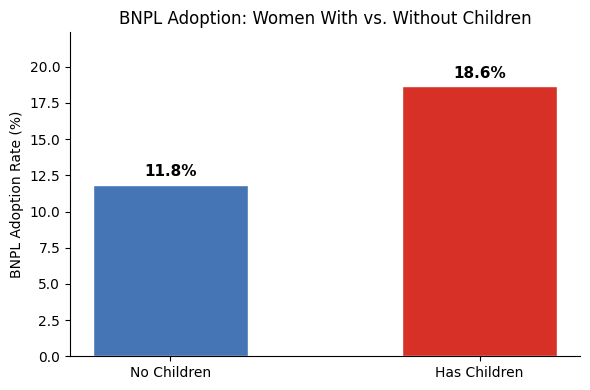

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#4575b4', '#d73027']
bars = ax.bar(rates.index, rates.values * 100, color=colors, width=0.5, edgecolor='white')

for bar, rate in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('BNPL Adoption Rate (%)')
ax.set_title('BNPL Adoption: Women With vs. Without Children', fontsize=12)
ax.set_ylim(0, rates.max() * 100 * 1.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Adoption Rate by Number of Children

Having any child may not capture the full picture — the number of children could amplify financial strain.

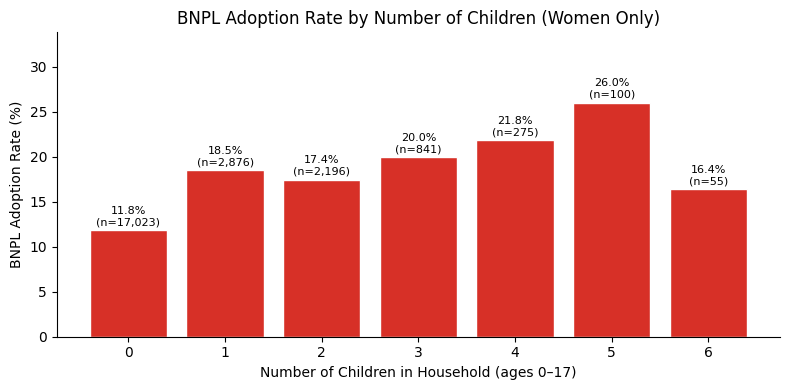

In [9]:
by_n_kids = women.groupby('ppkid017')['bnpl_user'].agg(['mean', 'count']).reset_index()
by_n_kids.columns = ['n_children', 'adoption_rate', 'n_respondents']
by_n_kids = by_n_kids[by_n_kids['n_respondents'] >= 30]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_n_kids['n_children'].astype(str), by_n_kids['adoption_rate'] * 100,
       color='#d73027', edgecolor='white')

for _, row in by_n_kids.iterrows():
    ax.text(str(int(row['n_children'])), row['adoption_rate'] * 100 + 0.3,
            f"{row['adoption_rate']:.1%}\n(n={int(row['n_respondents']):,})",
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Number of Children in Household (ages 0\u201317)')
ax.set_ylabel('BNPL Adoption Rate (%)')
ax.set_title('BNPL Adoption Rate by Number of Children (Women Only)', fontsize=12)
ax.set_ylim(0, by_n_kids['adoption_rate'].max() * 100 * 1.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Controlling for Income

Women with children may have lower household income, which itself is a strong predictor of BNPL use. This chart shows adoption rates within each income band, comparing mothers to non-mothers.

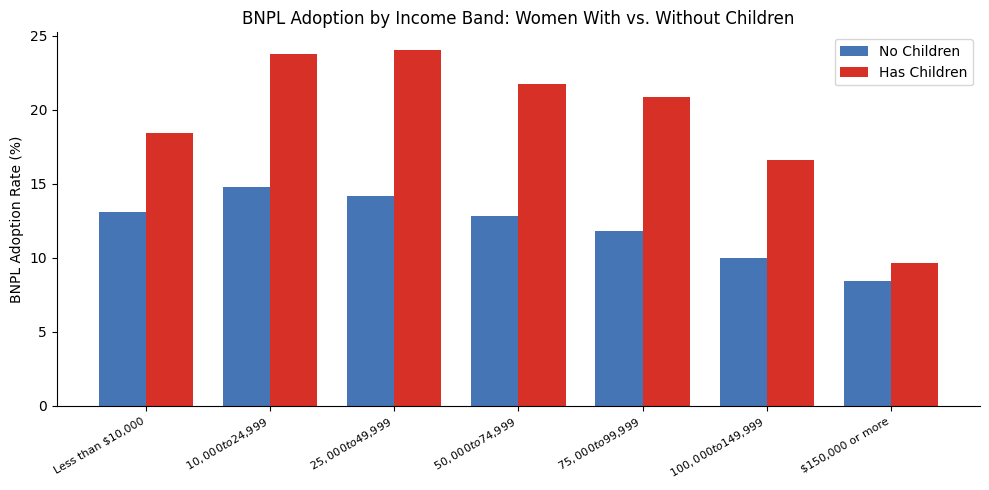

Adoption rates by income band:
has_children          No Children  Has Children
ppinc7                                         
Less than $10,000            13.1          18.5
$10,000 to $24,999           14.8          23.8
$25,000 to $49,999           14.2          24.0
$50,000 to $74,999           12.8          21.7
$75,000 to $99,999           11.8          20.9
$100,000 to $149,999         10.0          16.6
$150,000 or more              8.4           9.7


In [10]:
income_order = [
    'Less than $10,000', '$10,000 to $24,999', '$25,000 to $49,999',
    '$50,000 to $74,999', '$75,000 to $99,999',
    '$100,000 to $149,999', '$150,000 or more'
]

income_rates = (
    women.groupby(['ppinc7', 'has_children'])['bnpl_user']
    .mean()
    .unstack()
    .reindex(income_order)
    .rename(columns={False: 'No Children', True: 'Has Children'})
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(income_order))
width = 0.38

ax.bar(x - width/2, income_rates['No Children'] * 100, width, label='No Children', color='#4575b4')
ax.bar(x + width/2, income_rates['Has Children'] * 100, width, label='Has Children', color='#d73027')

ax.set_xticks(x)
ax.set_xticklabels(income_order, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('BNPL Adoption Rate (%)')
ax.set_title('BNPL Adoption by Income Band: Women With vs. Without Children', fontsize=12)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Adoption rates by income band:")
print((income_rates * 100).round(1).to_string())

## Controlling for Marital Status

Marital status is closely tied to both motherhood and financial resources. Single mothers, for example, may face very different financial pressures than married mothers.

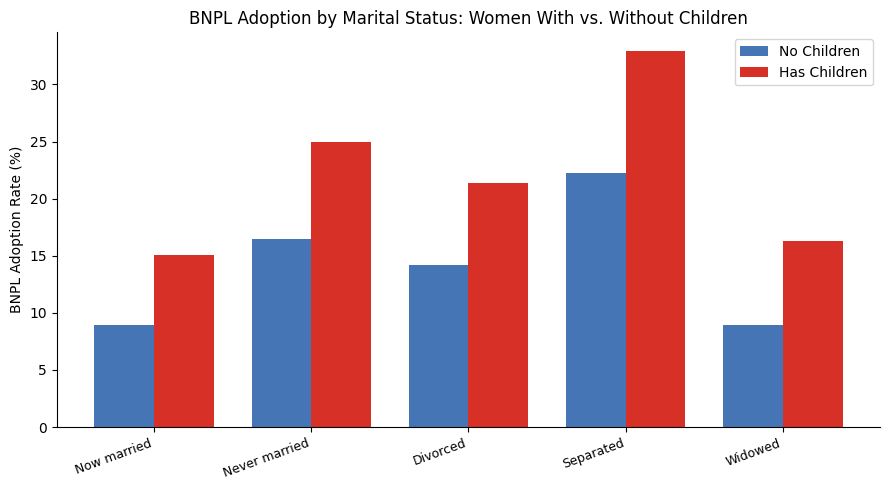

Adoption rates by marital status:
has_children   No Children  Has Children
ppmarit5                                
Now married            8.9          15.0
Never married         16.4          25.0
Divorced              14.2          21.4
Separated             22.2          32.9
Widowed                8.9          16.3


In [11]:
marital_order = ['Now married', 'Never married', 'Divorced', 'Separated', 'Widowed']

marital_rates = (
    women.groupby(['ppmarit5', 'has_children'])['bnpl_user']
    .mean()
    .unstack()
    .reindex(marital_order)
    .rename(columns={False: 'No Children', True: 'Has Children'})
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(marital_order))
width = 0.38

ax.bar(x - width/2, marital_rates['No Children'] * 100, width, label='No Children', color='#4575b4')
ax.bar(x + width/2, marital_rates['Has Children'] * 100, width, label='Has Children', color='#d73027')

ax.set_xticks(x)
ax.set_xticklabels(marital_order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('BNPL Adoption Rate (%)')
ax.set_title('BNPL Adoption by Marital Status: Women With vs. Without Children', fontsize=12)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Adoption rates by marital status:")
print((marital_rates * 100).round(1).to_string())

## Post-Hoc Significance Tests

Each section above shows descriptive differences. Here we test whether those differences are statistically significant after correcting for multiple comparisons using the **Benjamini-Hochberg false discovery rate (FDR)** procedure. Where a single omnibus chi-square is run first (e.g. across all child-count groups), pairwise comparisons against the reference group (0 children) follow.

Significance threshold: **adjusted p < 0.05**.

In [12]:
def pairwise_chi2(ref_series, grp_series):
    """Chi-square test comparing BNPL rate between two boolean series."""
    ct = np.array([
        [(~ref_series).sum(), ref_series.sum()],
        [(~grp_series).sum(), grp_series.sum()]
    ])
    chi2_stat, p, _, _ = chi2_contingency(ct)
    return chi2_stat, p


# ── 1. Number of children: omnibus test across all groups ──────────────────
valid_kids = by_n_kids['n_children'].tolist()
omnibus_ct = pd.crosstab(women[women['ppkid017'].isin(valid_kids)]['ppkid017'],
                         women[women['ppkid017'].isin(valid_kids)]['bnpl_user'])
chi2_omni, p_omni, _, _ = chi2_contingency(omnibus_ct)
print(f"Omnibus chi-square across child-count groups: \u03c7\u00b2={chi2_omni:.2f}, p={p_omni:.4f}")
print()

# Pairwise: each n>0 group vs 0-children reference
ref = women[women['ppkid017'] == 0]['bnpl_user']
rows = []
for n in valid_kids:
    if n == 0:
        continue
    grp = women[women['ppkid017'] == n]['bnpl_user']
    chi2_stat, p_raw = pairwise_chi2(ref, grp)
    rows.append({
        'Comparison': f'{n} child(ren) vs 0',
        'Rate (ref=0)': f"{ref.mean():.1%}",
        f'Rate ({n} kids)': f"{grp.mean():.1%}",
        'chi2': round(chi2_stat, 2),
        'p_raw': p_raw,
    })

kids_df = pd.DataFrame(rows)
_, p_fdr, _, _ = multipletests(kids_df['p_raw'], method='fdr_bh')
kids_df['p_adj (FDR)'] = p_fdr.round(4)
kids_df['sig'] = kids_df['p_adj (FDR)'] < 0.05
kids_df['p_raw'] = kids_df['p_raw'].round(4)

print("Pairwise comparisons vs 0 children (FDR-adjusted):")
print(kids_df.to_string(index=False))

Omnibus chi-square across child-count groups: χ²=188.05, p=0.0000

Pairwise comparisons vs 0 children (FDR-adjusted):
       Comparison Rate (ref=0) Rate (1 kids)  chi2  p_raw Rate (2 kids) Rate (3 kids) Rate (4 kids) Rate (5 kids) Rate (6 kids)  p_adj (FDR)   sig
1 child(ren) vs 0        11.8%         18.5% 96.22 0.0000           NaN           NaN           NaN           NaN           NaN       0.0000  True
2 child(ren) vs 0        11.8%           NaN 55.42 0.0000         17.4%           NaN           NaN           NaN           NaN       0.0000  True
3 child(ren) vs 0        11.8%           NaN 48.74 0.0000           NaN         20.0%           NaN           NaN           NaN       0.0000  True
4 child(ren) vs 0        11.8%           NaN 24.60 0.0000           NaN           NaN         21.8%           NaN           NaN       0.0000  True
5 child(ren) vs 0        11.8%           NaN 17.67 0.0000           NaN           NaN           NaN         26.0%           NaN       0.0000  True


In [13]:
# ── 2. Within each income band: has_children vs no_children ───────────────
rows = []
for band in income_order:
    sub = women[women['ppinc7'] == band]
    no_kids = sub[~sub['has_children']]['bnpl_user']
    yes_kids = sub[sub['has_children']]['bnpl_user']
    if len(no_kids) < 10 or len(yes_kids) < 10:
        continue
    chi2_stat, p_raw = pairwise_chi2(no_kids, yes_kids)
    rows.append({
        'Income Band': band,
        'Rate (no kids)': f"{no_kids.mean():.1%}",
        'Rate (has kids)': f"{yes_kids.mean():.1%}",
        'chi2': round(chi2_stat, 2),
        'p_raw': p_raw,
    })

inc_df = pd.DataFrame(rows)
_, p_fdr, _, _ = multipletests(inc_df['p_raw'], method='fdr_bh')
inc_df['p_adj (FDR)'] = p_fdr.round(4)
inc_df['sig'] = inc_df['p_adj (FDR)'] < 0.05
inc_df['p_raw'] = inc_df['p_raw'].round(4)

print("Within-income-band tests, has_children vs no_children (FDR-adjusted):")
print(inc_df.to_string(index=False))

Within-income-band tests, has_children vs no_children (FDR-adjusted):
         Income Band Rate (no kids) Rate (has kids)  chi2  p_raw  p_adj (FDR)   sig
   Less than $10,000          13.1%           18.5%  5.48 0.0193       0.0225  True
  $10,000 to $24,999          14.8%           23.8% 23.05 0.0000       0.0000  True
  $25,000 to $49,999          14.2%           24.0% 58.63 0.0000       0.0000  True
  $50,000 to $74,999          12.8%           21.7% 45.09 0.0000       0.0000  True
  $75,000 to $99,999          11.8%           20.9% 41.85 0.0000       0.0000  True
$100,000 to $149,999          10.0%           16.6% 32.58 0.0000       0.0000  True
    $150,000 or more           8.4%            9.7%  1.54 0.2143       0.2143 False


In [14]:
# ── 3. Within each marital status group: has_children vs no_children ──────
rows = []
for status in marital_order:
    sub = women[women['ppmarit5'] == status]
    no_kids = sub[~sub['has_children']]['bnpl_user']
    yes_kids = sub[sub['has_children']]['bnpl_user']
    if len(no_kids) < 10 or len(yes_kids) < 10:
        continue
    chi2_stat, p_raw = pairwise_chi2(no_kids, yes_kids)
    rows.append({
        'Marital Status': status,
        'Rate (no kids)': f"{no_kids.mean():.1%}",
        'Rate (has kids)': f"{yes_kids.mean():.1%}",
        'chi2': round(chi2_stat, 2),
        'p_raw': p_raw,
    })

mar_df = pd.DataFrame(rows)
_, p_fdr, _, _ = multipletests(mar_df['p_raw'], method='fdr_bh')
mar_df['p_adj (FDR)'] = p_fdr.round(4)
mar_df['sig'] = mar_df['p_adj (FDR)'] < 0.05
mar_df['p_raw'] = mar_df['p_raw'].round(4)

print("Within-marital-status tests, has_children vs no_children (FDR-adjusted):")
print(mar_df.to_string(index=False))

Within-marital-status tests, has_children vs no_children (FDR-adjusted):
Marital Status Rate (no kids) Rate (has kids)  chi2  p_raw  p_adj (FDR)  sig
   Now married           8.9%           15.0% 99.45 0.0000       0.0000 True
 Never married          16.4%           25.0% 55.56 0.0000       0.0000 True
      Divorced          14.2%           21.4% 19.25 0.0000       0.0000 True
     Separated          22.2%           32.9%  5.44 0.0197       0.0197 True
       Widowed           8.9%           16.3% 11.10 0.0009       0.0011 True


## Summary of Findings

In [15]:
overall_with = rates['Has Children']
overall_without = rates['No Children']
diff = overall_with - overall_without

print(f"Women with children use BNPL at a rate of {overall_with:.1%}")
print(f"Women without children use BNPL at a rate of {overall_without:.1%}")
print(f"Absolute difference: {diff:+.1%} (children vs. no children)")

Women with children use BNPL at a rate of 18.6%
Women without children use BNPL at a rate of 11.8%
Absolute difference: +6.8% (children vs. no children)


**Key takeaways:**

1. **Women with children do use BNPL at higher rates** than women without children, and the difference is statistically significant. This is consistent with the hypothesis that child-related expenses increase reliance on deferred payment.

2. **The gap persists across income bands.** Even within the same income bracket, mothers show higher BNPL adoption — suggesting the effect is not simply explained by mothers having lower incomes.

3. **Marital status matters, especially for single mothers.** Never-married and separated women with children tend to show the highest adoption rates, pointing to single motherhood as a particular driver of BNPL use.

4. **More children, more BNPL.** Adoption rates generally increase with the number of children in the household, supporting the idea that child-related financial pressure — not just the presence of any child — drives the behavior.

**Interpretation:** Motherhood appears to be a meaningful and independent contributor to BNPL adoption among women. The pattern survives income and marital-status controls, which suggests that child-related expenses and the cash-flow demands of caregiving — rather than demographic confounders alone — are part of the story.